In [89]:
import pandas as pd  # Mengimpor pustaka pandas untuk manipulasi dan analisis data
import matplotlib.pyplot as plt  # Mengimpor pustaka matplotlib untuk visualisasi grafik
from yellowbrick.cluster import KElbowVisualizer  # Mengimpor KElbowVisualizer untuk visualisasi metode Elbow
 
from sklearn.cluster import KMeans, DBSCAN  # Mengimpor algoritma KMeans dan DBSCAN untuk clustering
from sklearn.metrics import silhouette_score  # Mengimpor silhouette_score untuk mengevaluasi hasil clustering

In [90]:
df = pd.read_csv('data.csv')

df

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
0,0.803,0.6240,7,-6.764,0,0.0477,0.4510,0.000734,0.1000,0.6280,95.968,304524,4,0
1,0.762,0.7030,10,-7.951,0,0.3060,0.2060,0.000000,0.0912,0.5190,151.329,247178,4,1
2,0.261,0.0149,1,-27.528,1,0.0419,0.9920,0.897000,0.1020,0.0382,75.296,286987,4,0
3,0.722,0.7360,3,-6.994,0,0.0585,0.4310,0.000001,0.1230,0.5820,89.860,208920,4,1
4,0.787,0.5720,1,-7.516,1,0.2220,0.1450,0.000000,0.0753,0.6470,155.117,179413,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.166,0.0551,9,-19.494,0,0.0520,0.9760,0.635000,0.1190,0.1430,176.616,206520,3,0
191,0.862,0.6240,3,-11.630,1,0.0565,0.0192,0.000153,0.0465,0.8820,124.896,254240,4,0
192,0.499,0.3510,9,-11.509,0,0.0448,0.9510,0.000099,0.1180,0.6160,90.664,235947,4,0
193,0.574,0.7290,10,-5.838,0,0.0965,0.0406,0.000004,0.1940,0.4130,110.547,190239,5,1


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      195 non-null    float64
 1   energy            195 non-null    float64
 2   key               195 non-null    int64  
 3   loudness          195 non-null    float64
 4   mode              195 non-null    int64  
 5   speechiness       195 non-null    float64
 6   acousticness      195 non-null    float64
 7   instrumentalness  195 non-null    float64
 8   liveness          195 non-null    float64
 9   valence           195 non-null    float64
 10  tempo             195 non-null    float64
 11  duration_ms       195 non-null    int64  
 12  time_signature    195 non-null    int64  
 13  liked             195 non-null    int64  
dtypes: float64(9), int64(5)
memory usage: 21.5 KB


In [92]:
df.describe()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,liked
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,0.636656,0.638431,5.497436,-9.481631,0.538462,0.148957,0.319093,0.192337,0.148455,0.493632,121.086174,213408.933333,3.912821,0.512821
std,0.216614,0.260096,3.415209,6.525086,0.499802,0.120414,0.320782,0.346226,0.105975,0.267695,28.084829,72152.392864,0.451332,0.501122
min,0.130000,0.002400,0.000000,-42.261000,0.000000,0.027800,0.000003,0.000000,0.033100,0.035300,60.171000,77203.000000,1.000000,0.000000
25%,0.462500,0.533500,2.000000,-9.962000,0.000000,0.056800,0.042200,0.000000,0.084000,0.269000,100.242000,178300.500000,4.000000,0.000000
50%,0.705000,0.659000,6.000000,-7.766000,1.000000,0.096200,0.213000,0.000008,0.105000,0.525000,124.896000,204000.000000,4.000000,1.000000
75%,0.799000,0.837500,8.000000,-5.829000,1.000000,0.230500,0.504000,0.097500,0.177000,0.717500,142.460500,242373.500000,4.000000,1.000000
max,0.946000,0.996000,11.000000,-2.336000,1.000000,0.540000,0.995000,0.969000,0.633000,0.980000,180.036000,655213.000000,5.000000,1.000000


In [93]:
from sklearn.preprocessing import StandardScaler
#mengambil fitur yg ingin di kelompokan
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]
#scaling (tidak wajib ya)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [94]:
#setelah scaling
pd.DataFrame(X_scaled, columns=features)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.769903,-0.055628,0.417562,-0.843078,0.412263,-0.554830,-0.458413,0.503237,-0.896670
1,0.580139,0.248888,0.235180,1.307549,-0.353462,-0.556955,-0.541666,0.095009,1.079610
2,-1.738685,-2.403485,-2.772810,-0.891369,2.103110,2.040507,-0.439492,-1.705687,-1.634621
3,0.395003,0.376091,0.382222,-0.753156,0.349755,-0.556952,-0.240821,0.330957,-1.114714
4,0.695849,-0.256069,0.302018,0.608158,-0.544112,-0.556955,-0.692088,0.574396,1.214835
...,...,...,...,...,...,...,...,...,...
190,-2.178382,-2.248529,-1.538392,-0.807276,2.053103,1.281828,-0.278663,-1.313189,1.982307
191,1.042978,-0.055628,-0.330095,-0.769808,-0.937289,-0.556512,-0.964551,1.454520,0.136003
192,-0.637128,-1.107943,-0.311504,-0.867223,1.974968,-0.556667,-0.288124,0.458295,-1.086013
193,-0.289998,0.349108,0.559841,-0.436765,-0.870405,-0.556943,0.430876,-0.301983,-0.376228


C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set

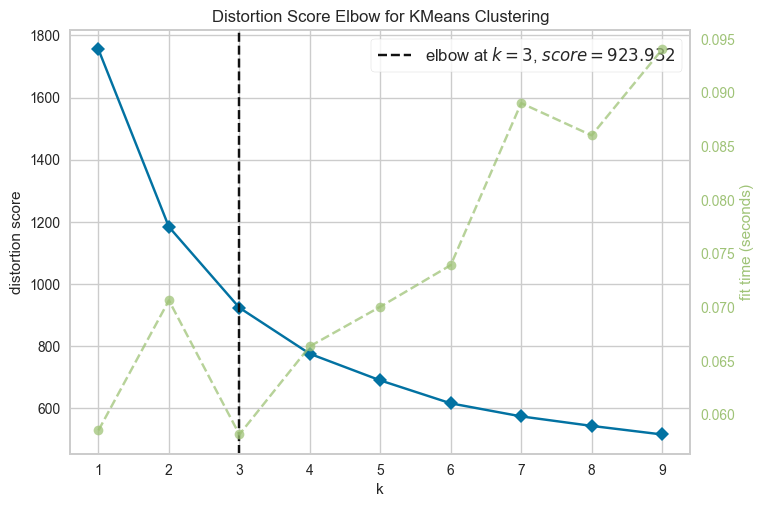

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [95]:
#elbow method before modelling

# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()
 
# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
 
# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X_scaled)
 
# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [96]:
from sklearn.cluster import KMeans
 
# Inisialisasi dan melatih model KMeans dengan jumlah cluster = 4
kmeans = KMeans(n_clusters=3, random_state=0)
kmeans.fit(X_scaled)
 
# Mendapatkan label cluster
labels = kmeans.labels_

df['cluster'] = labels


#ubah nama cluster
def label_cluster(c):
    if c == 0:
        return 'Party'
    elif c == 1:
        return 'Chill'
    else:
        return 'Energetic'

df['segment'] = df['cluster'].apply(label_cluster)


#analisis setiap cluster
cluster_summary = df.groupby('segment')[features].mean()
print(cluster_summary)

C:\Users\dodih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


           danceability    energy   loudness  speechiness  acousticness  \
segment                                                                   
Chill          0.319478  0.104137 -24.274870     0.044687      0.940565   
Energetic      0.314731  0.973808  -6.412538     0.113062      0.000220   
Party          0.743952  0.662877  -7.697740     0.171776      0.277976   

           instrumentalness  liveness   valence       tempo  
segment                                                      
Chill              0.820996  0.133322  0.123448  100.255522  
Energetic          0.661563  0.196065  0.278615  113.634038  
Party              0.009741  0.142361  0.590239  125.694808  


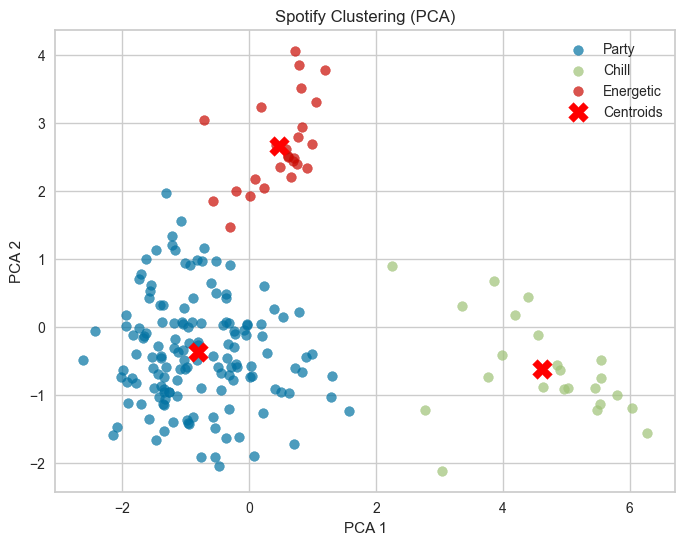

In [97]:
plt.figure(figsize=(8,6))

for segment in df['segment'].unique():
    subset = df[df['segment'] == segment]
    idx = subset.index
    
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=segment,
        alpha=0.7
    )

# centroid
plt.scatter(centroids_pca[:,0], centroids_pca[:,1],
            c='red', s=200, marker='X', label='Centroids')

plt.title('Spotify Clustering (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [98]:
#evaluasi sihouette score
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.3587351209793947


In [99]:
import pandas as pd

# coba data baru
test_data = pd.DataFrame([{
    "danceability": 0.80,
    "energy": 0.72,
    "loudness": -5.5,
    "speechiness": 0.10,
    "acousticness": 0.15,
    "instrumentalness": 0.00,
    "liveness": 0.12,
    "valence": 0.75,
    "tempo": 132
}])

# scaling
test_scaled = scaler.transform(test_data[features])

# prediksi
cluster = kmeans.predict(test_scaled)[0]

# mapping
def label_cluster(c):
    if c == 0:
        return "Party"
    elif c == 1:
        return "Chill"
    else:
        return "Energetic"

segment = label_cluster(cluster)

# hasil
print("Cluster:", cluster)
print("Segment:", segment)

Cluster: 0
Segment: Party


In [100]:
import joblib

joblib.dump(kmeans, "kmeans_spotify.pkl")
joblib.dump(scaler, "scaler_spotify.pkl")

print("model dan scaler disimpan")

model dan scaler disimpan
